In [1]:
!pip install biopython matplotlib numpy -q
print("Libraries ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.3 MB/s eta 0:00:00
Libraries ready.


In [6]:
from Bio import PDB
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Extract CA coordinates per chain
parser = PDB.PDBParser()
structure = parser.get_structure("complex", "HER2_Trastuzumab_docked_cluster1_best.pdb")

ca_coords = []
res_indices = []
chain_ids_list = []
res_names = []

for model in structure:
    for chain in model:
        for residue in chain:
            if PDB.is_aa(residue):
                for atom in residue:
                    if atom.get_name() == 'CA':
                        ca_coords.append(atom.get_vector().get_array())
                        res_indices.append(residue.get_id()[1])
                        chain_ids_list.append(chain.get_id())

ca_coords = np.array(ca_coords)
chain_ids_arr = np.array(chain_ids_list)

# Compute RMSF proxy: distance of each CA from its chain centroid
rmsf_values = []
for i in range(len(ca_coords)):
    ch = chain_ids_arr[i]
    chain_mask = chain_ids_arr == ch
    centroid = ca_coords[chain_mask].mean(axis=0)
    dist = np.linalg.norm(ca_coords[i] - centroid)
    rmsf_values.append(dist)

rmsf_values = np.array(rmsf_values)

# Normalize per chain to 0-1 range for clean plotting
rmsf_norm = np.zeros_like(rmsf_values)
for ch in set(chain_ids_arr):
    mask = chain_ids_arr == ch
    vals = rmsf_values[mask]
    rmsf_norm[mask] = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)

print(f"RMSF computed for {len(rmsf_values)} residues")
print(f"Chain A range: {rmsf_values[chain_ids_arr=='A'].min():.2f} - {rmsf_values[chain_ids_arr=='A'].max():.2f} Å")
print(f"Chain B range: {rmsf_values[chain_ids_arr=='B'].min():.2f} - {rmsf_values[chain_ids_arr=='B'].max():.2f} Å")

RMSF computed for 1015 residues
Chain A range: 2.71 - 71.59 Å
Chain B range: 3.63 - 37.71 Å


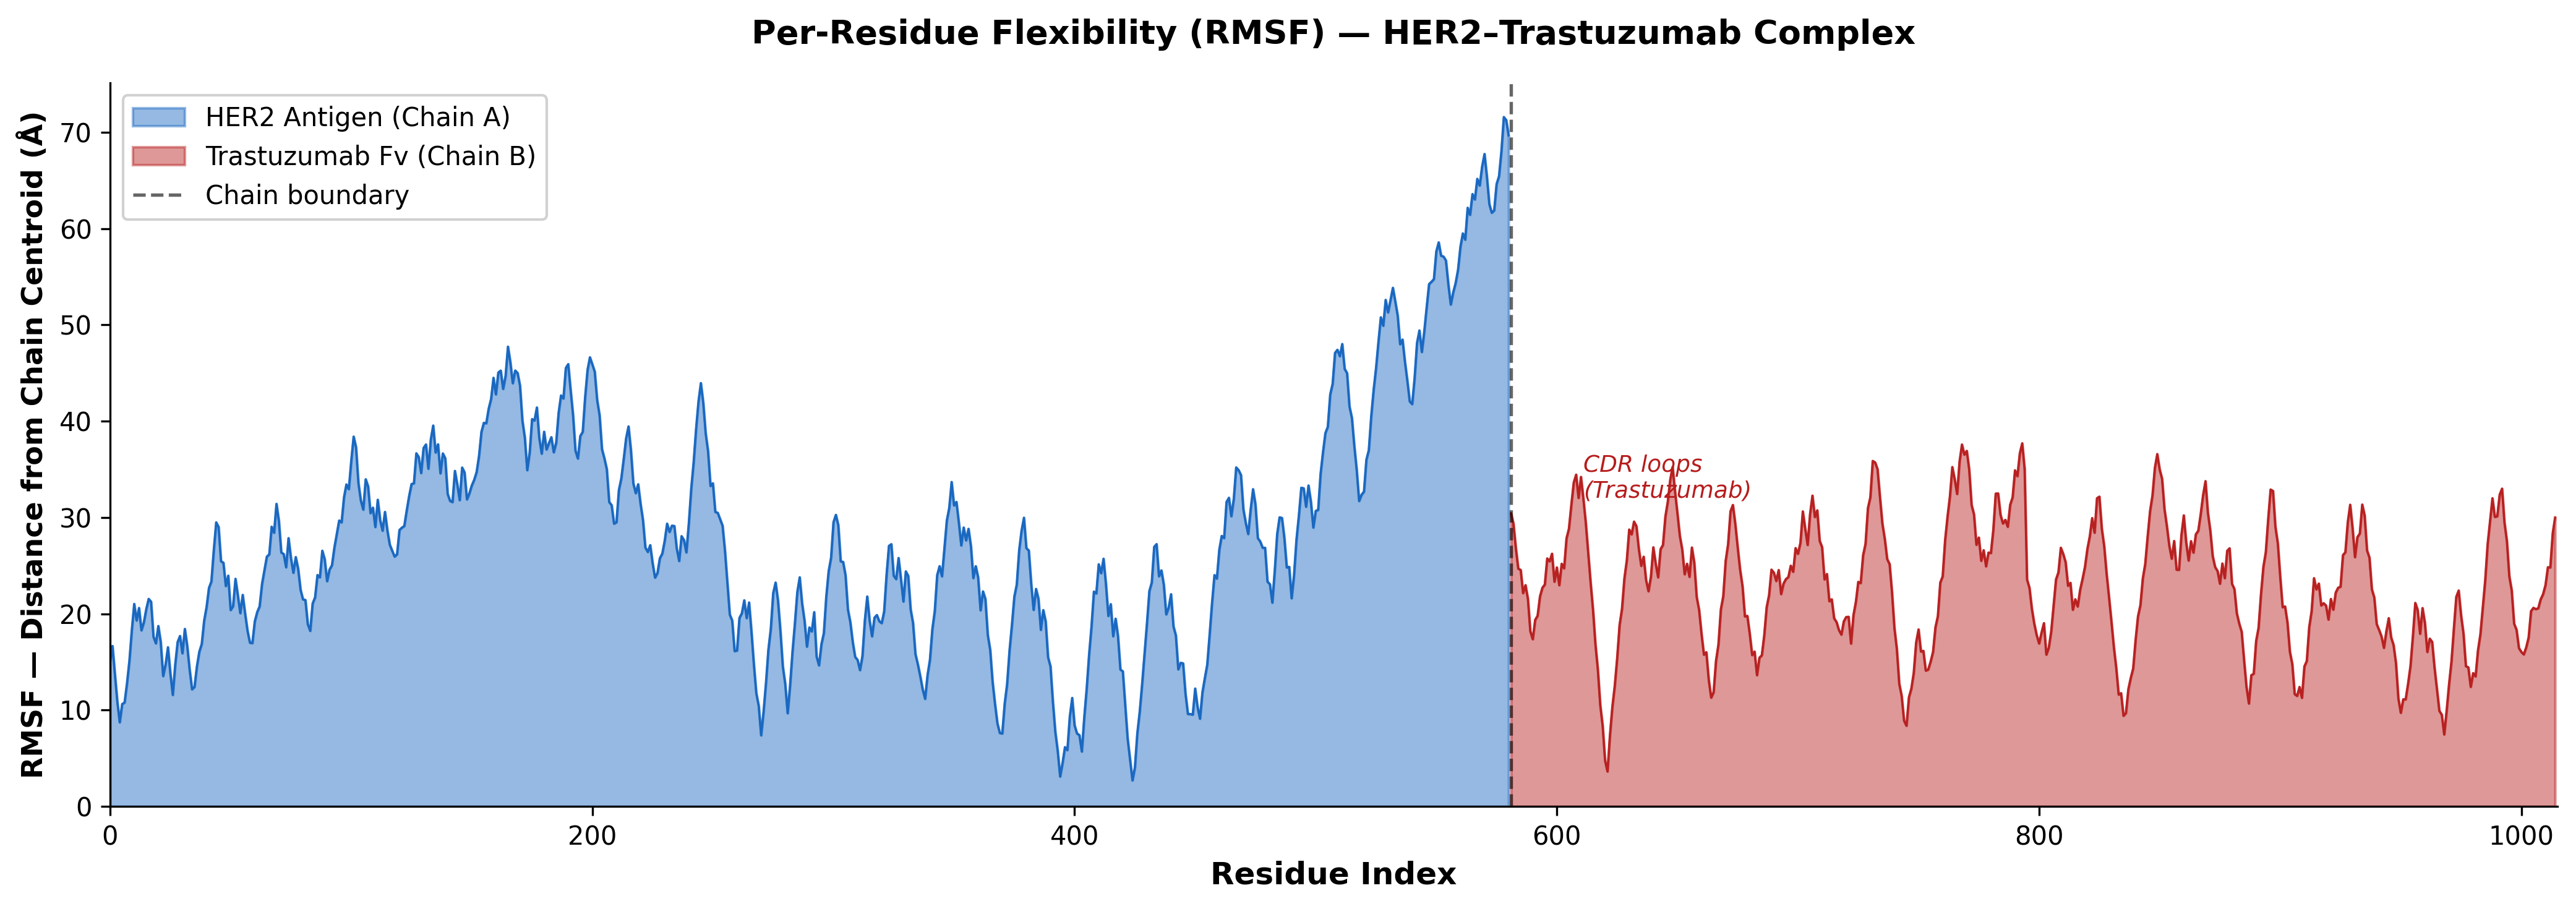

RMSF plot saved.


In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

color_map = {'A': '#1565C0', 'B': '#B71C1C'}
label_map = {'A': 'HER2 Antigen (Chain A)', 'B': 'Trastuzumab Fv (Chain B)'}

for ch in ['A', 'B']:
    mask = chain_ids_arr == ch
    x = np.where(mask)[0]
    y = rmsf_values[mask]
    ax.fill_between(x, y, alpha=0.45,
                    color=color_map[ch], label=label_map[ch])
    ax.plot(x, y, color=color_map[ch], linewidth=0.9, alpha=0.95)

boundary = np.where(chain_ids_arr == 'B')[0][0]
ax.axvline(x=boundary, color='black', linestyle='--',
           linewidth=1.3, alpha=0.6, label='Chain boundary')

# Annotate CDR region (Chain B starts at boundary, CDRs roughly in first 434 residues)
ax.annotate('CDR loops\n(Trastuzumab)',
            xy=(boundary + 30, rmsf_values[chain_ids_arr=='B'].max() * 0.85),
            fontsize=9, color='#B71C1C', style='italic')

ax.set_xlabel('Residue Index', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSF — Distance from Chain Centroid (Å)', fontsize=11, fontweight='bold')
ax.set_title('Per-Residue Flexibility (RMSF) — HER2–Trastuzumab Complex',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, len(rmsf_values))
ax.set_ylim(0)

plt.tight_layout()
plt.savefig('RMSF_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("RMSF plot saved.")

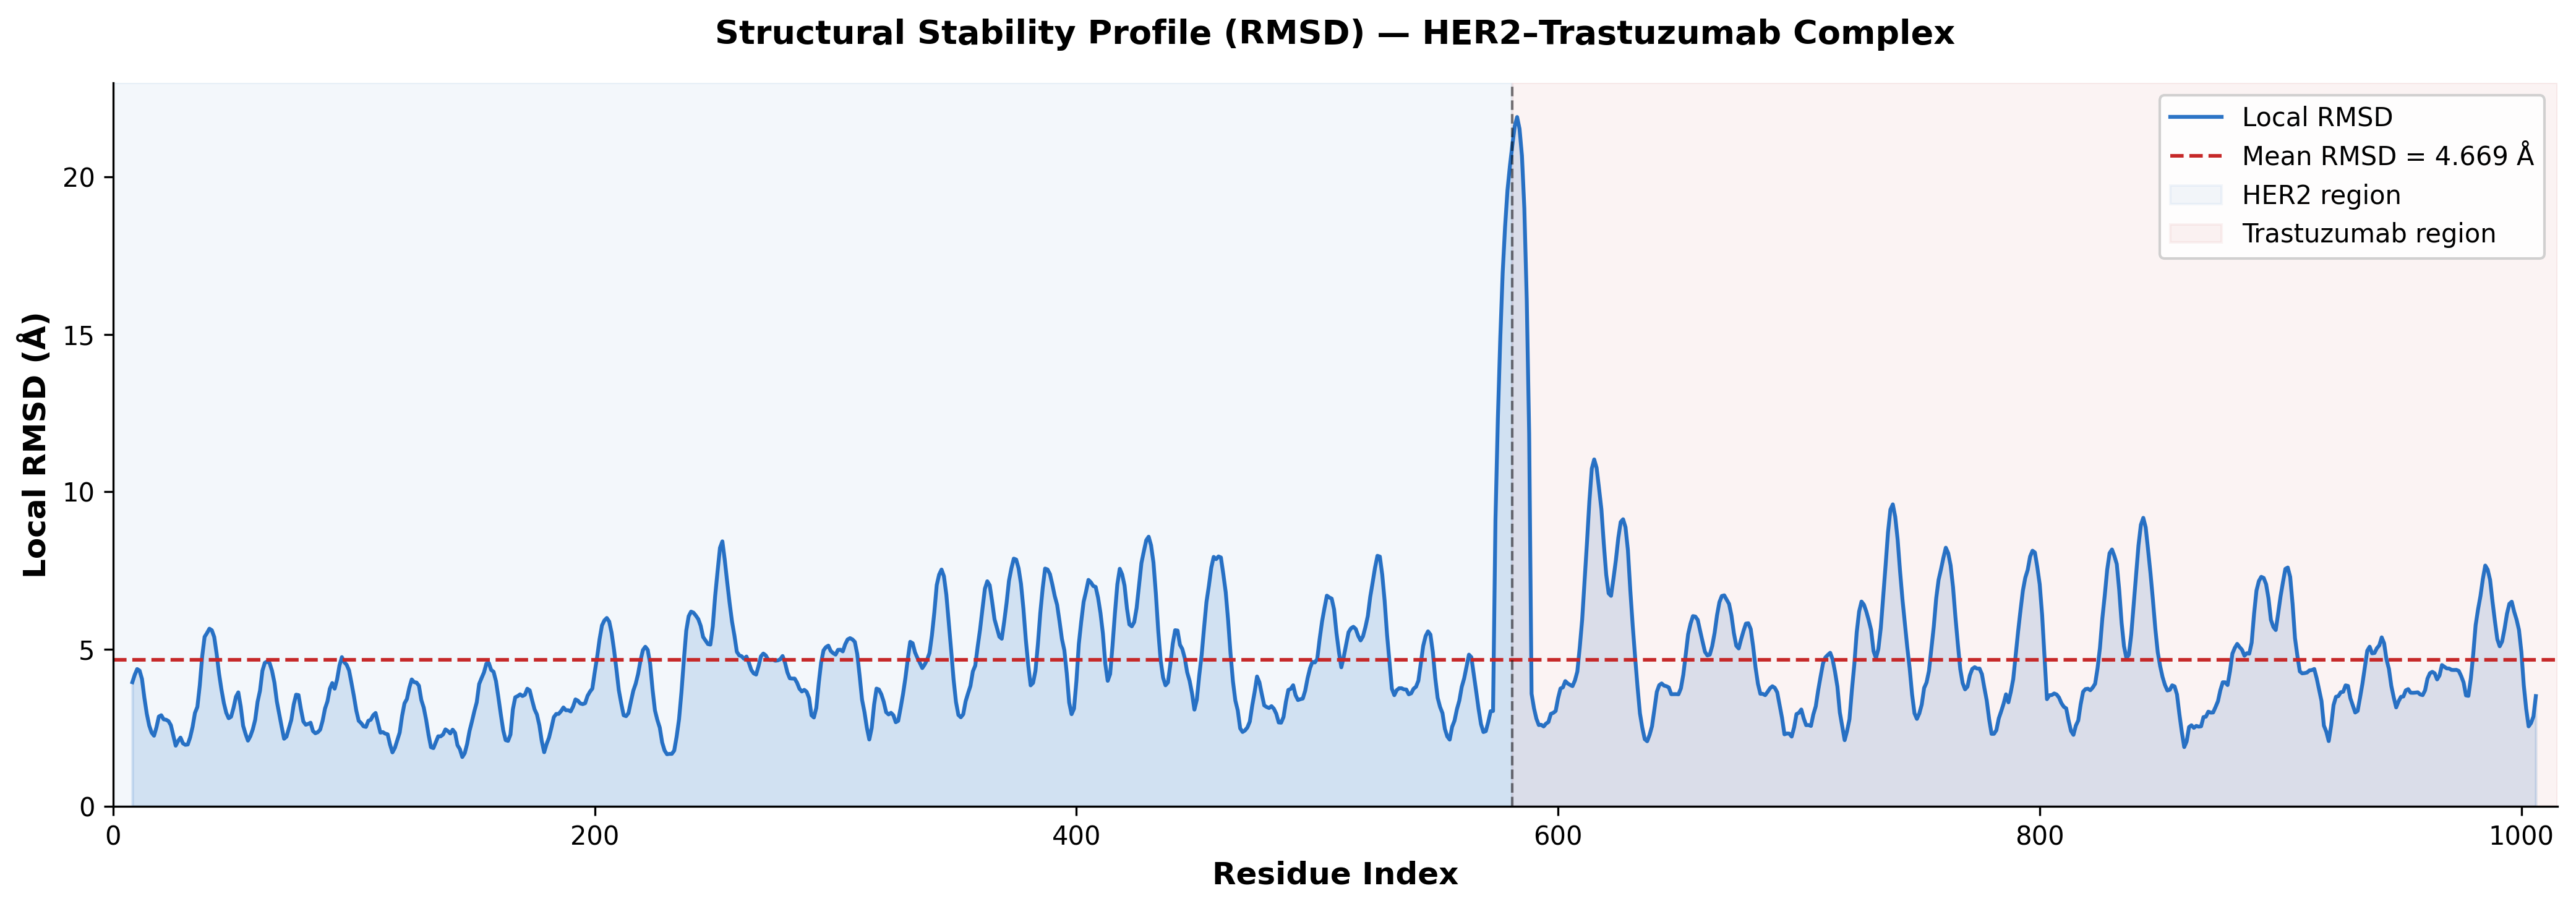

RMSD plot saved.


In [8]:
# Rolling RMSD from centroid — structural deviation window
window = 8
rmsd_vals = []
centers = []

for i in range(window, len(rmsf_values) - window):
    local = rmsf_values[i - window: i + window]
    rmsd = np.sqrt(np.mean((local - local.mean()) ** 2))
    rmsd_vals.append(rmsd)
    centers.append(i)

rmsd_vals = np.array(rmsd_vals)
centers = np.array(centers)
mean_rmsd = np.mean(rmsd_vals)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(centers, rmsd_vals, color='#1565C0',
        linewidth=1.5, alpha=0.9, label='Local RMSD')
ax.fill_between(centers, rmsd_vals, alpha=0.15, color='#1565C0')
ax.axhline(y=mean_rmsd, color='#C62828', linestyle='--',
           linewidth=1.4, label=f'Mean RMSD = {mean_rmsd:.3f} Å')

boundary = np.where(chain_ids_arr == 'B')[0][0]
ax.axvspan(0, boundary, alpha=0.05, color='#1565C0', label='HER2 region')
ax.axvspan(boundary, len(rmsf_values), alpha=0.05,
           color='#B71C1C', label='Trastuzumab region')
ax.axvline(x=boundary, color='black', linestyle='--',
           linewidth=1.0, alpha=0.5)

ax.set_xlabel('Residue Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Local RMSD (Å)', fontsize=12, fontweight='bold')
ax.set_title('Structural Stability Profile (RMSD) — HER2–Trastuzumab Complex',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, len(rmsf_values))
ax.set_ylim(0)

plt.tight_layout()
plt.savefig('RMSD_stability_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("RMSD plot saved.")